## Course End Project - Sales Analysis

#Data Wrangling

In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('AusApparalSales4thQrt2020.csv')
df.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [252]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


In [253]:
df.describe()

,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [254]:
print("States: ", df['State'].unique())
print("Time: ",df['Time'].unique())
print("Groups: ",df['Group'].unique())

States:  [' WA' ' NT' ' SA' ' VIC' ' QLD' ' NSW' ' TAS']
Time:  [' Morning' ' Afternoon' ' Evening']
Groups:  [' Kids' ' Men' ' Women' ' Seniors']


In [255]:
df.isna().sum()

,0
Date,0
Time,0
State,0
Group,0
Unit,0
Sales,0


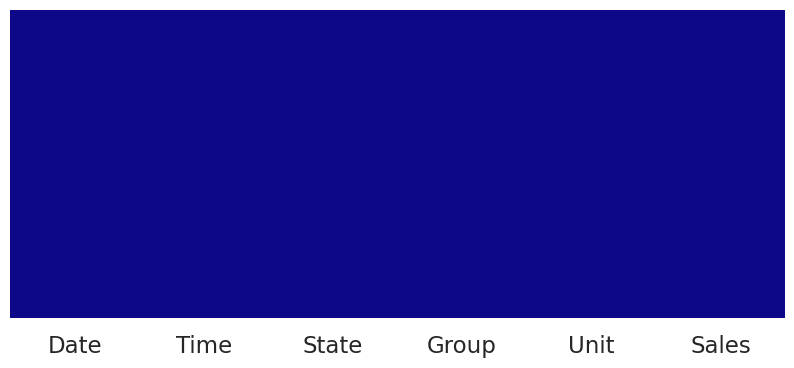

In [256]:
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='plasma')
plt.show()

No missing Values in the data set

In [257]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['Unit', 'Sales']] = scaler.fit_transform(df[['Unit', 'Sales']])
df

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,0.015873,0.015873
...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,0.190476,0.190476
7556,30-Dec-2020,Evening,TAS,Kids,0.206349,0.206349
7557,30-Dec-2020,Evening,TAS,Men,0.206349,0.206349
7558,30-Dec-2020,Evening,TAS,Women,0.142857,0.142857


In [258]:
state_sales_sum = df.groupby(['State', 'Group'])['Sales'].sum().unstack()
print(state_sales_sum)
print()
state_sales_mean = df.groupby('State')['Sales'].mean()
print(state_sales_mean)

Group        Kids         Men     Seniors       Women
State                                                
NSW    109.444444  112.206349  106.904762  113.158730
NT      27.619048   28.015873   26.126984   27.317460
QLD     45.460317   44.714286   43.428571   44.285714
SA      83.587302   84.476190   84.873016   86.476190
TAS     28.095238   27.984127   27.301587   26.841270
VIC    158.793651  159.095238  158.507937  159.571429
WA      27.142857   27.952381   26.428571   24.841270

State
NSW    0.408995
NT     0.100999
QLD    0.164712
SA     0.314271
TAS    0.102058
VIC    0.588859
WA     0.098486
Name: Sales, dtype: float64


# GroupBy() analysis

Using the groupby() function helped to aggregate the data efficiently and helped analyze sales data from all the states listed.
Using it showcased the high and low performing regions to allow for breakdown of the numbers for future planning. Using groupby() for such insight is useful for the future as well

-----------------------------------------------------------------

## 2. Data Analysis

In [259]:
real_df = pd.read_csv('AusApparalSales4thQrt2020.csv')
real_df['Date'] = pd.to_datetime(real_df['Date'])
real_df.head()

,Date,Time,State,Group,Unit,Sales
0,2020-10-01,Morning,WA,Kids,8,20000
1,2020-10-01,Morning,WA,Men,8,20000
2,2020-10-01,Morning,WA,Women,4,10000
3,2020-10-01,Morning,WA,Seniors,15,37500
4,2020-10-01,Afternoon,WA,Kids,3,7500


In [260]:
desc = real_df[['Sales', 'Unit']].agg(['min', 'max', 'mean', 'median', 'std']).T
desc

,min,max,mean,median,std
Sales,5000.0,162500.0,45013.558201,35000.0,32253.506944
Unit,2.0,65.0,18.005423,14.0,12.901403


In [261]:
print("Mode Sales: ", list(real_df['Sales'].mode()))
print("Mode Unit: ", list(real_df['Unit'].mode()))

Mode Sales:  [22500]
Mode Unit:  [9]


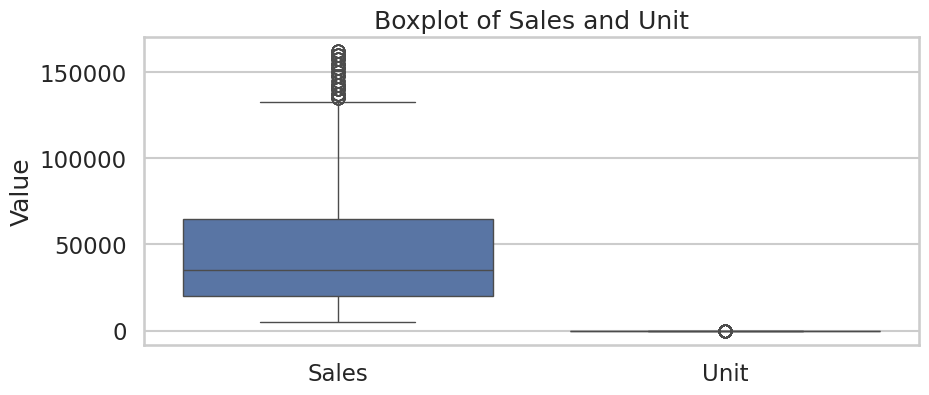

In [353]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=real_df[['Sales', 'Unit']])
plt.title('Boxplot of Sales and Unit')
plt.ylabel('Value')
plt.show()

In [263]:
# Generate Weekly, Monthly, Quarterly Reports

real_df['Week'] = real_df['Date'].dt.isocalendar().week
real_df['Month'] = real_df['Date'].dt.month
real_df['Quarter'] = real_df['Date'].dt.quarter
real_df.head()

,Date,Time,State,Group,Unit,Sales,Week,Month,Quarter
0,2020-10-01,Morning,WA,Kids,8,20000,40,10,4
1,2020-10-01,Morning,WA,Men,8,20000,40,10,4
2,2020-10-01,Morning,WA,Women,4,10000,40,10,4
3,2020-10-01,Morning,WA,Seniors,15,37500,40,10,4
4,2020-10-01,Afternoon,WA,Kids,3,7500,40,10,4


In [262]:
group_sales = real_df.groupby('Group')['Sales'].sum().sort_values(ascending=False)
group_sales

,Sales
Group,
Men,85750000
Women,85442500
Kids,85072500
Seniors,84037500


In [264]:
daily = real_df.groupby('Date')['Sales'].sum().reset_index()
print("Daily report:\n", daily.head())

Daily report:
         Date    Sales
0 2020-10-01  3720000
1 2020-10-02  3715000
2 2020-10-03  3890000
3 2020-10-04  3720000
4 2020-10-05  3862500


In [265]:
weekly = real_df.groupby('Week')['Sales'].sum().reset_index()
print("Weekly report:\n", weekly.head())

Weekly report:
    Week     Sales
0    40  15045000
1    41  27002500
2    42  26640000
3    43  26815000
4    44  21807500


In [323]:
monthly = real_df.groupby('Month')['Sales'].sum().reset_index()
print("Monthly report:\n", monthly.head())

Monthly report:
    Month      Sales
0     10  114290000
1     11   90682500
2     12  135330000


In [324]:
quarterly = real_df.groupby('Quarter')['Sales'].sum().reset_index()
print("Quarterly report:\n", quarterly.head())

Quarterly report:
    Quarter      Sales
0        4  340302500


-----------------------------------------------------------------

## 3. Data Visualization

In [268]:
sns.set_style(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,4)

df = real_df.copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Week'] = df['Date'].dt.isocalendar().week
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df.head()

,Date,Time,State,Group,Unit,Sales,Week,Month,Quarter
0,2020-10-01,Morning,WA,Kids,8,20000,40,10,4
1,2020-10-01,Morning,WA,Men,8,20000,40,10,4
2,2020-10-01,Morning,WA,Women,4,10000,40,10,4
3,2020-10-01,Morning,WA,Seniors,15,37500,40,10,4
4,2020-10-01,Afternoon,WA,Kids,3,7500,40,10,4


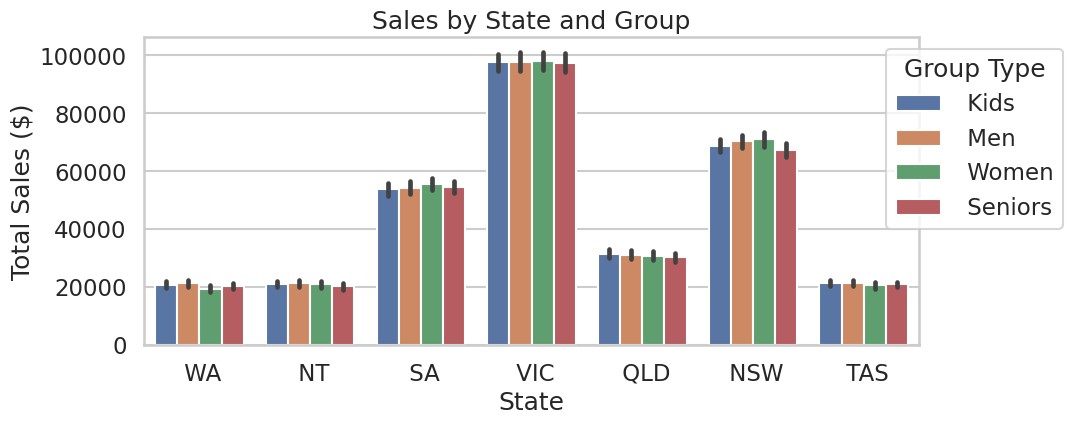

In [269]:
sns.barplot(data=df, x='State', y='Sales', hue='Group')
plt.title('Sales by State and Group')
plt.ylabel('Total Sales ($)')
plt.xlabel('State')
plt.legend(title='Group Type', bbox_to_anchor=(1.2, 1) ,loc='upper right')
plt.show()

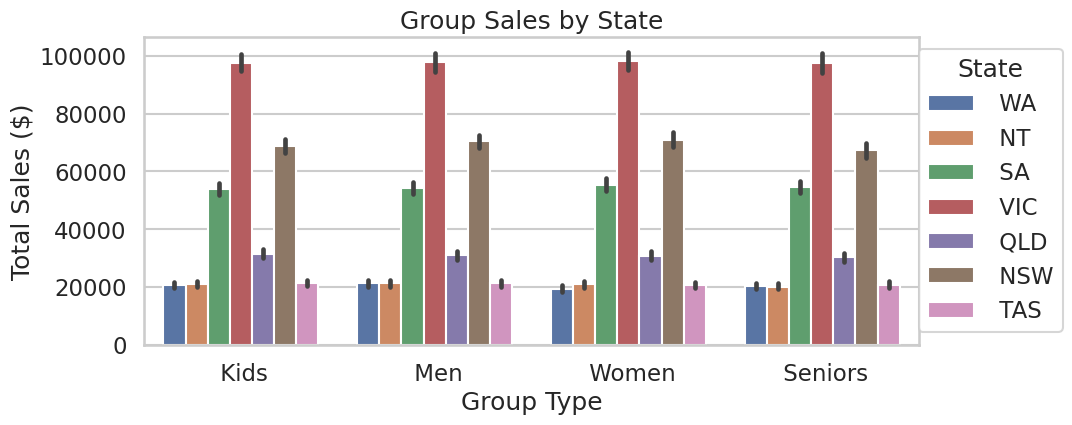

In [270]:
sns.barplot(data=df, x='Group', y='Sales', hue='State')
plt.title('Group Sales by State')
plt.ylabel('Total Sales ($)')
plt.xlabel('Group Type')
plt.legend(title='State', bbox_to_anchor=(1.2, 1), loc='upper right')
plt.show()

## Bar Chart Takeaway

- State and Group Chart
  - VIC and NSW show the highest total sales across the groups, showing that this area is the brands strongest markets
  -While WA, NT, TAS show the lowest sales in the data, signaling something more can be done to boost sales
- Sales by State Chart
  - Sales across the groups continue to be highest in VIC and NSW with SA not far behind
  - Shows that AAL has broad appeal for all groups

In [271]:
time_sales = df.groupby('Time')['Sales'].mean().sort_values(ascending=False)
time_sales

,Sales
Time,
Morning,45320.436508
Afternoon,45241.071429
Evening,44479.166667


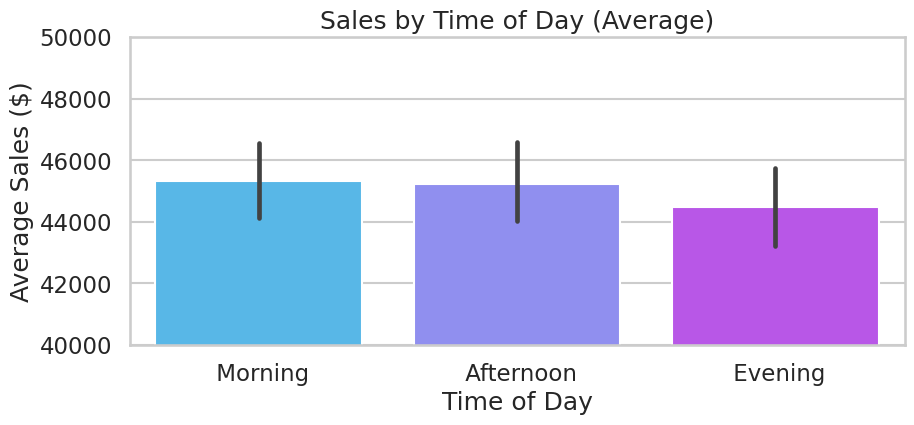

In [349]:
sns.barplot(data=df, x='Time', y='Sales', hue='Time', palette='cool')
plt.title('Sales by Time of Day (Average)')
plt.ylabel('Average Sales ($)')
plt.xlabel('Time of Day')
plt.ylim(40000, 50000)
plt.show()

In [273]:
df.head()

,Date,Time,State,Group,Unit,Sales,Week,Month,Quarter
0,2020-10-01,Morning,WA,Kids,8,20000,40,10,4
1,2020-10-01,Morning,WA,Men,8,20000,40,10,4
2,2020-10-01,Morning,WA,Women,4,10000,40,10,4
3,2020-10-01,Morning,WA,Seniors,15,37500,40,10,4
4,2020-10-01,Afternoon,WA,Kids,3,7500,40,10,4


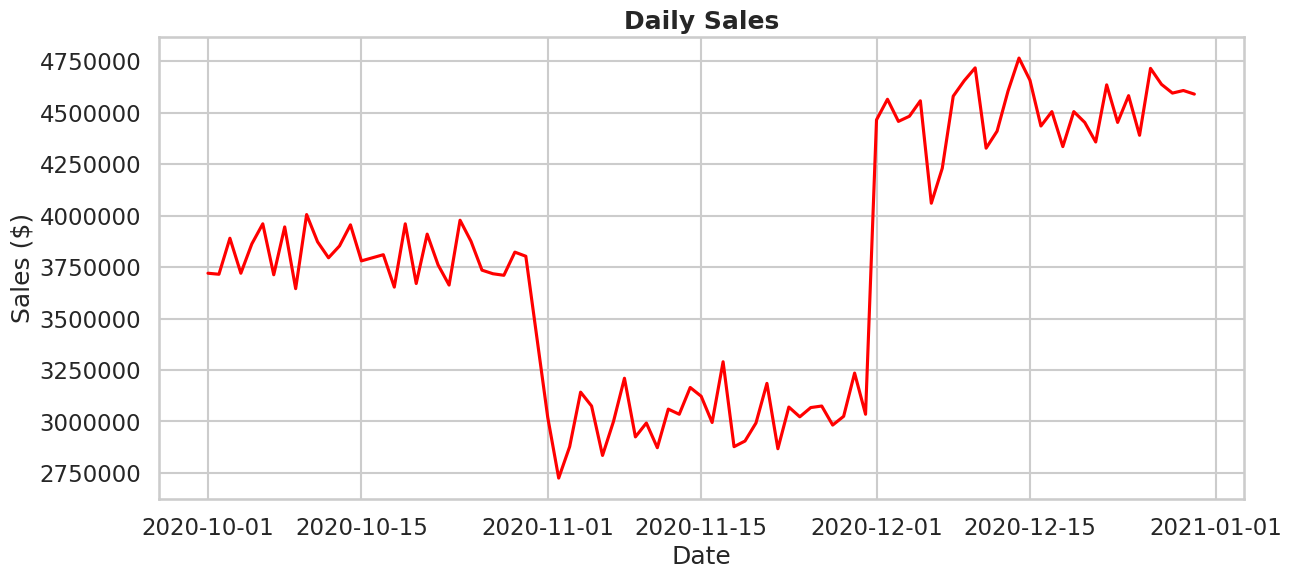

In [348]:
def pdaily(daily):
  plt.figure(figsize=(14, 6))
  sns.lineplot(data=daily, x='Date', y='Sales', color='red')
  plt.title('Daily Sales', fontweight='bold')
  plt.ylabel('Sales ($)')
  plt.xlabel('Date')
  plt.ticklabel_format(style='plain', axis='y')

pdaily(daily)

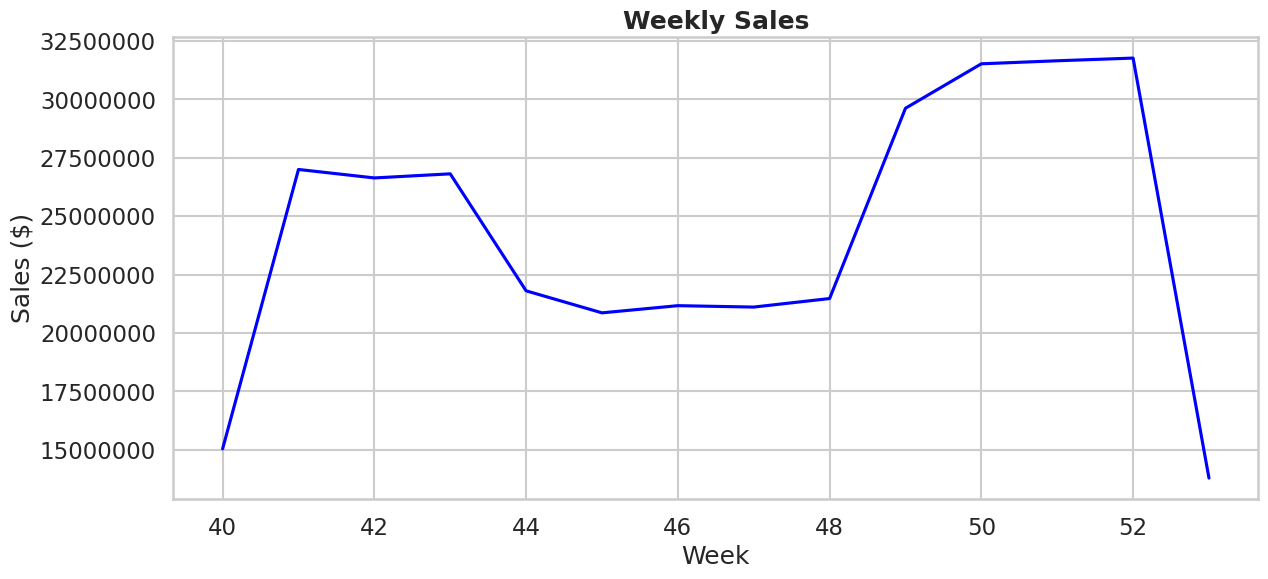

In [347]:
def pweekly(weekly):
  plt.figure(figsize=(14, 6))
  sns.lineplot(data=weekly, x='Week', y='Sales', color='blue')
  plt.title('Weekly Sales', fontweight='bold')
  plt.ylabel('Sales ($)')
  plt.xlabel('Week')
  plt.ticklabel_format(style='plain', axis='y')

pweekly(weekly)

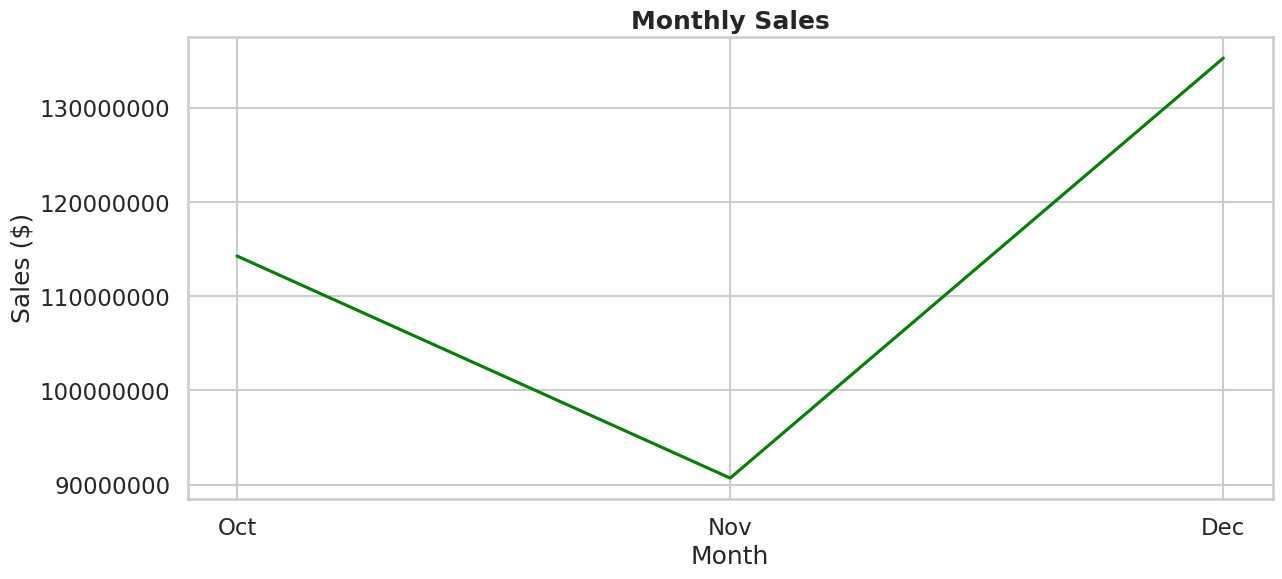

In [346]:
def pmonthly(monthly):
  plt.figure(figsize=(14, 6))
  month_map = {10: 'Oct', 11: 'Nov', 12: 'Dec'}
  monthly['MonthLabel'] = monthly['Month'].map(month_map)
  sns.lineplot(data=monthly, x='MonthLabel', y='Sales', color='green')
  plt.title('Monthly Sales', fontweight='bold')
  plt.ylabel('Sales ($)')
  plt.xlabel('Month')
  plt.ticklabel_format(style='plain', axis='y')

pmonthly(monthly)

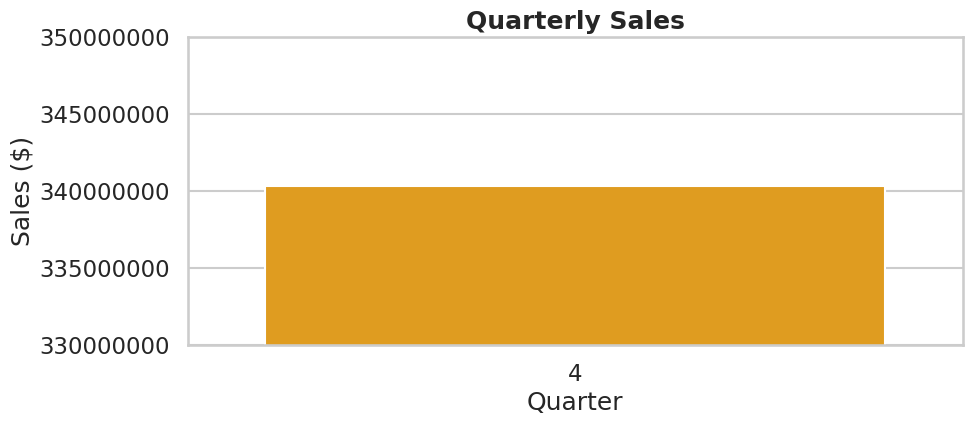

In [345]:
def pquarterly(quarterly):
  sns.barplot(data=quarterly, x='Quarter', y='Sales', color='orange')
  plt.title('Quarterly Sales', fontweight='bold')
  plt.ylabel('Sales ($)')
  plt.xlabel('Quarter')
  plt.ylim(330000000, 350000000)
  plt.ticklabel_format(style='plain', axis='y')

pquarterly(quarterly)

## Visualization Recommendation

For the visualization of the data, Seaborn is a good choice to showcase the data. It provides a clear, easy to read interface for the charts such as bar, line charts. It also allows for easy use with Pandas DataFrames and allows it to be displayed in a colorful maner as well.

## Summarization

- VIC and NSW lead the way for generating the highest sales for the company in the fourth-quarter, while some other states are behind in sales.
- Seems avg sales were the highest during the day, while the off-peak hours were in the evening
- Time-Based
  - Seems based on monthly and daily graphs that the month of November had a significant dip followed by a stronger December
  - This may be because of the Holiday season

Overall, the data shows a clear pattern of how the different groups in different states produce different results and can be studied to allow for other regions to learn from them to get better results.